In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

LOADING DATASET

In [18]:
(x_train,y_train),(x_test,y_test) = keras.datasets.mnist.load_data()

NORMALIZING THE DATASET

In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

FLATTENING THE DATASET

In [ ]:
x_train_flattened = x_train.reshape(len(x_train), 784)
x_test_flattened = x_test.reshape(len(x_test), 784)


In [ ]:
CHECKING IF DATASET IS OK

In [12]:
print("Train shape:", x_train.shape)
print("Labels shape:", y_train.shape)
print("Pixel range:", x_train.min(), x_train.max())
print("Unique labels:", np.unique(y_train))

Train shape: (60000, 28, 28)
Labels shape: (60000,)
Pixel range: 0.0 1.5378700499807765e-05
Unique labels: [0 1 2 3 4 5 6 7 8 9]


MAKING THE LAYERS
1 -> INPUT LAYER
2 -> 1 HIDDEN LAYER OF 100 NEURONS
3 -> 2 HIDDEN LAYER CONSISTING OF 50 NEURONS
4 -> FINAL OUTPUT LAYER WHICH GIVE A CONFIDENCE SCORE ON NUMBER FROM 0-9 

In [5]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [ ]:
CONFIGURING THE MODEL
ADAM OPTIMIZER FOR ADJUSTING WEIGHTS 
LOSS FUNCTION -> SPARSE CROSSENTROPY

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

TRAINING THE MODEL
X_TRAIN FLATTENEND -> THE IMAGES WE GENERATED FROM THE DATASET BY FLATTENING THEM
Y_TRAIN -> ACTUAL OUTPUT WILL COMPARE AGAINST THESE
EPOCHS -> 5 WHICH MEANS WILL RUN THE WHOLE PROCESS ON THE ENTIRE DATASET 5 TIMES
BATCH_SIZE -> 30 WHICH MEANS WILL PROCESS 30 IMAGES ALL TOGETHER
VALIDATION SPLIT -> 10 PERCENT RESERVED FOR TESTING MODEL

In [21]:
model.fit(
    x_train_flattened,
    y_train,
    epochs=5,
    batch_size=30,
    validation_split=0.1
)

Epoch 1/5
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9940 - loss: 0.0181 - val_accuracy: 0.9773 - val_loss: 0.1142
Epoch 2/5
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9951 - loss: 0.0145 - val_accuracy: 0.9757 - val_loss: 0.1358
Epoch 3/5
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9948 - loss: 0.0147 - val_accuracy: 0.9738 - val_loss: 0.1498
Epoch 4/5
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9950 - loss: 0.0144 - val_accuracy: 0.9780 - val_loss: 0.1292
Epoch 5/5
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9958 - loss: 0.0134 - val_accuracy: 0.9790 - val_loss: 0.1271


In [ ]:
MAKING LABELS BASED ON TEST SET

In [16]:
y_pred_prob = model.predict(x_test_flattened)
y_pred = np.argmax(y_pred_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
TO EVALUATE THE MODEL 

In [25]:
test_loss, test_accuracy = model.evaluate(
    x_test_flattened,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy * 100, "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9754 - loss: 0.1239
Test Loss: 0.1238839253783226
Test Accuracy: 97.53999710083008 %


In [10]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.4 MB 6.5 MB/s eta 0:00:02
   ------------- -------------------------- 2.9/8.4 MB 7.6 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.4 MB 7.2 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.4 MB 6.8 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.4 MB 6.6 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.4 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 6.6 MB/s  0:00:01
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   - -------------------------------------- 1.3/37.4 MB 7.2 MB/s eta 0:00:06
   -- ------------------------------------- 2.6/37.4 MB 6.7 MB/s eta 0:00:06
   ---- ----------------------------------- 3.9/37.4 MB 6.3 MB/s eta 0:00:06
   ----- ---------------------------------- 5.2/37.4 MB 6.4 MB/s eta 0:00:06
   ------ --------------

In [ ]:
DISPLAYING THE CONFUSION MATRIX

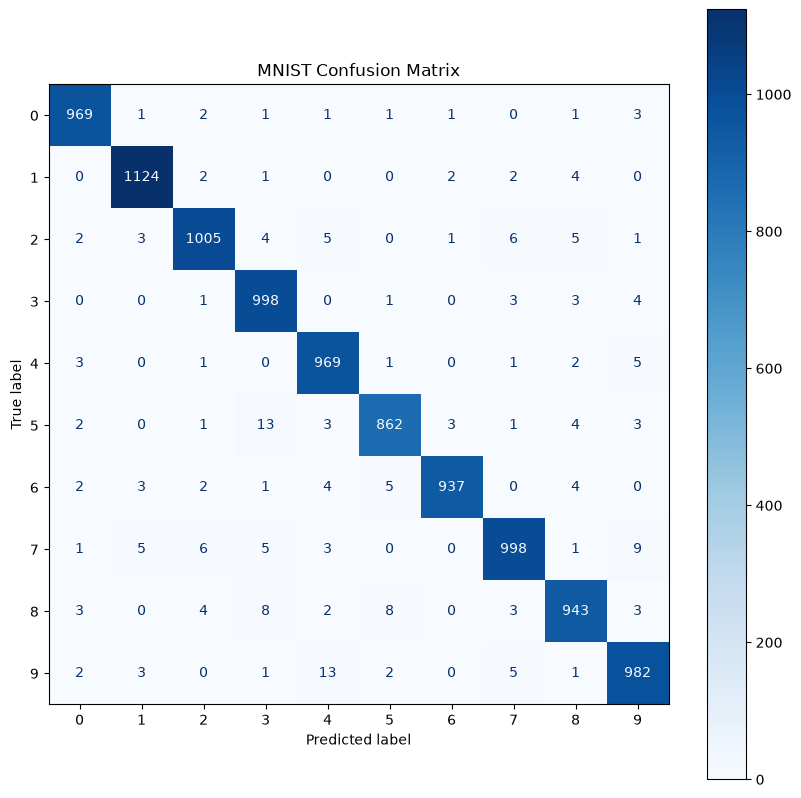

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

fig, ax = plt.subplots(figsize=(10, 10))
display.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("MNIST Confusion Matrix")
plt.show()

In [22]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt


In [23]:

report = classification_report(
    y_test,
    y_pred,
    target_names=[str(i) for i in range(10)],
    output_dict=True
)



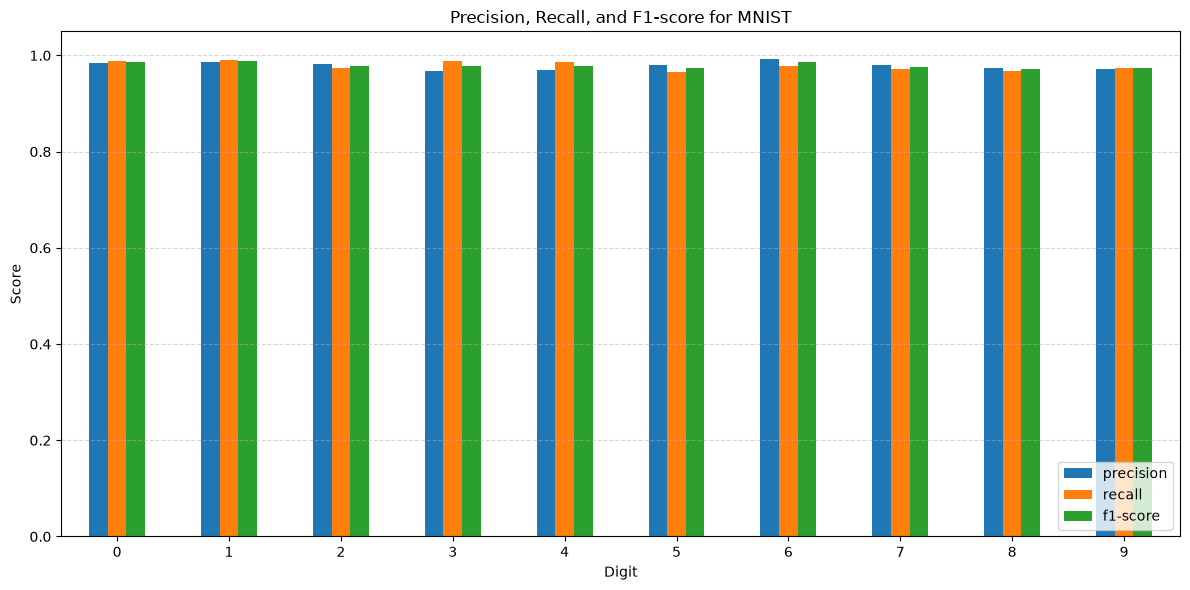

In [24]:
df = pd.DataFrame(report).transpose()

df = df.loc[[str(i) for i in range(10)], ["precision", "recall", "f1-score"]]

df.plot(kind="bar", figsize=(12, 6))

plt.title("Precision, Recall, and F1-score for MNIST")
plt.xlabel("Digit")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
model.save("mnist_model.keras")